# Dataset 2: DAIR-AI Emotion — Data Cleaning & Preprocessing
**Model target:** Model 1 — Emotion Classifier (combined with GoEmotions)  
**Source:** `dair-ai/emotion` (HuggingFace Datasets Hub)  
**Task:** 6-class basic emotion classification  

---
## 2.1 Dataset Description
DAIR-AI Emotion contains 20,000 English Twitter messages labelled with six basic emotions: sadness, joy, love, anger, fear, and surprise. It provides cleaner, shorter-text emotion examples to complement GoEmotions' longer Reddit comments.

**Why combine with GoEmotions?**  
GoEmotions has 27 nuanced emotion classes from Reddit (longer, complex text). DAIR-AI has 6 clear basic emotions from Twitter (shorter, punchy text). Training on both makes Model 1 robust to both short emotional outbursts ('I'm terrified') and longer emotional narratives.

In [2]:
import re, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid')
LABEL_NAMES = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
print('Ready.')

Ready.


In [3]:
raw = load_dataset('dair-ai/emotion', 'split')
print(raw)
df = raw['train'].to_pandas()
print(f'\nShape: {df.shape}')
print(f'Nulls: {df.isnull().sum().to_dict()}')
print(f'\nLabel distribution:')
vc = df['label'].value_counts().sort_index()
for idx, count in vc.items():
    print(f'  {LABEL_NAMES[idx]:12s}: {count:,}')
print(f'\nImbalance ratio: {vc.max()/vc.min():.1f}x')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Shape: (16000, 2)
Nulls: {'text': 0, 'label': 0}

Label distribution:
  sadness     : 4,666
  joy         : 5,362
  love        : 1,304
  anger       : 2,159
  fear        : 1,937
  surprise    : 572

Imbalance ratio: 9.4x


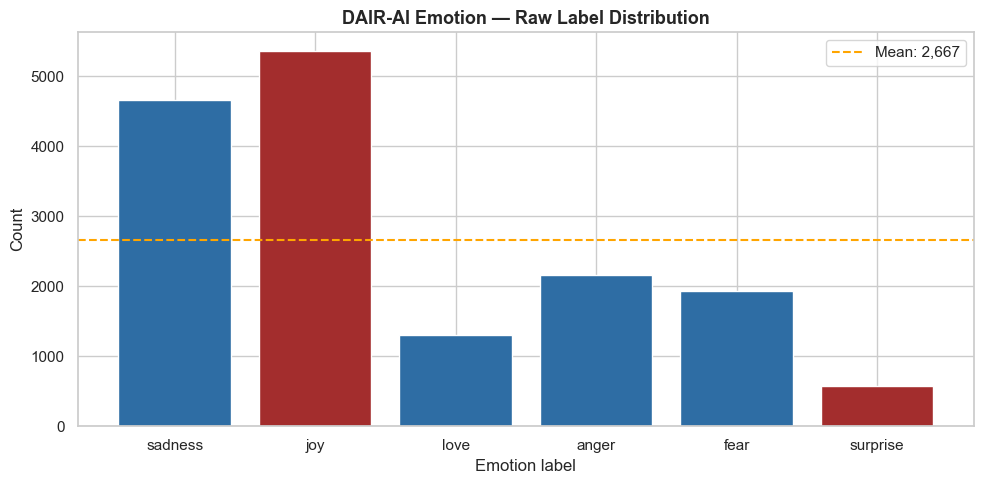

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
vc = df['label'].value_counts().sort_index()
names = [LABEL_NAMES[i] for i in vc.index]
counts = vc.values
colors = ['#A32D2D' if c == max(counts) or c == min(counts) else '#2E6DA4' for c in counts]
ax.bar(names, counts, color=colors, edgecolor='white')
ax.axhline(np.mean(counts), color='orange', linestyle='--', label=f'Mean: {np.mean(counts):,.0f}')
ax.set_title('DAIR-AI Emotion — Raw Label Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion label')
ax.set_ylabel('Count')
ax.legend()
import os
os.makedirs('figures', exist_ok=True)
plt.tight_layout()
plt.savefig('figures/02a_dair_emotion_raw_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── EDA: Noise patterns specific to Twitter ──────────────────────
print('Checking Twitter-specific noise patterns...\n')

mention_count = df['text'].str.contains(r'@\w+', regex=True).sum()
rt_count      = df['text'].str.contains(r'^RT ', regex=True).sum()
hashtag_count = df['text'].str.contains(r'#\w+', regex=True).sum()
url_count     = df['text'].str.contains(r'https?://', regex=True).sum()

print(f'@mentions      : {mention_count:,}')
print(f'RT prefixes    : {rt_count:,}')
print(f'#hashtags      : {hashtag_count:,}')
print(f'URLs           : {url_count:,}')

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(f'\nWord count stats:')
print(df['word_count'].describe())

# Why min_words=3 for Twitter (not 5 like GoEmotions):
short_examples = df[df['word_count'] < 5].head(5)
print(f'\nShort examples (< 5 words) — do these carry emotion signal?')
for _, row in short_examples.iterrows():
    print(f'  [{LABEL_NAMES[row["label"]]:8s}] {row["text"]}')

Checking Twitter-specific noise patterns...

@mentions      : 0
RT prefixes    : 0
#hashtags      : 0
URLs           : 0

Word count stats:
count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: word_count, dtype: float64

Short examples (< 5 words) — do these carry emotion signal?
  [sadness ] i didnt feel humiliated
  [anger   ] i am feeling grouchy
  [love    ] i feel romantic too
  [anger   ] im feeling cranky
  [sadness ] i feel stressed always


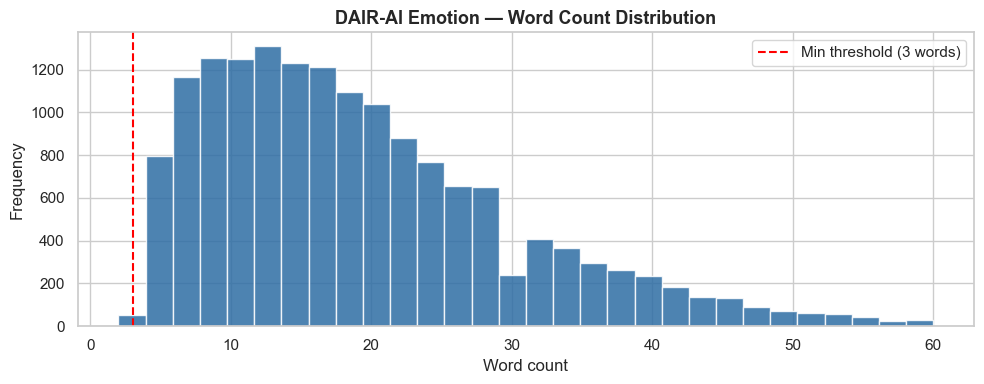

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['word_count'].clip(upper=60), bins=30, color='#2E6DA4', edgecolor='white', alpha=0.85)
ax.axvline(3, color='red', linestyle='--', label='Min threshold (3 words)')
ax.set_title('DAIR-AI Emotion — Word Count Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('figures/02b_dair_emotion_word_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Cleaning function for Twitter text ───────────────────────────
RE_URL     = re.compile(r'https?://\S+|www\.\S+')
RE_MENTION = re.compile(r'@\w+')
RE_RT      = re.compile(r'^RT\s+', re.IGNORECASE)
RE_HASH    = re.compile(r'#(\w+)')  # remove #, keep word
RE_SPACE   = re.compile(r'[ \t]+')

def clean_tweet(text, min_words=3, max_words=100):
    """
    Clean a single tweet for emotion classification.

    Steps:
      1. Type guard
      2. Unicode normalisation
      3. Remove retweet prefix (RT @user:)
         Why: RT prefix is metadata, not emotional content
      4. Remove @mentions
         Why: Usernames don't generalise — unique tokens that
         never appear at test time with the same meaning
      5. Remove URLs
         Why: No emotional signal
      6. Clean hashtags — remove # but keep the word
         Why: '#anxiety' and 'anxiety' should be the same
         token. The # character creates a rare sub-word token
         that appears only in hashtag context
      7. Keep emoji (do NOT remove)
         Why: Emoji are strong emotion signals on Twitter.
         '😭' strongly predicts sadness. Removing emoji loses
         signal that measurably improves classification accuracy
      8. Collapse whitespace
      9. Min length filter (3 words — Twitter texts are short)
    """
    if not isinstance(text, str) or not text.strip():
        return None
    text = unicodedata.normalize('NFKC', text)
    text = RE_RT.sub('', text)           # Step 3
    text = RE_MENTION.sub('', text)      # Step 4
    text = RE_URL.sub('', text)          # Step 5
    text = RE_HASH.sub(r'\1', text)     # Step 6 — keep word
    text = RE_SPACE.sub(' ', text).strip()
    words = text.split()
    if len(words) < min_words:
        return None
    return ' '.join(words[:max_words])

# Test
tests = [
    'RT @user: I feel so hopeless today',
    '@friend I am feeling really #anxious about this',
    'lol',
    'I am so happy 😊 life is amazing',
]
for t in tests:
    print(f'IN : {t}')
    print(f'OUT: {clean_tweet(t)}\n')

IN : RT @user: I feel so hopeless today
OUT: : I feel so hopeless today

IN : @friend I am feeling really #anxious about this
OUT: I am feeling really anxious about this

IN : lol
OUT: None

IN : I am so happy 😊 life is amazing
OUT: I am so happy 😊 life is amazing



In [8]:
# Apply cleaning and save
from tqdm.auto import tqdm

cleaned = {}
for split_name in ['train', 'validation', 'test']:
    split = raw[split_name]
    texts, labels, label_names = [], [], []
    skipped = 0
    for ex in tqdm(split, desc=split_name):
        c = clean_tweet(str(ex['text']))
        if c is None:
            skipped += 1
            continue
        texts.append(c)
        labels.append(ex['label'])
        label_names.append(LABEL_NAMES[ex['label']])
    cleaned[split_name] = {'texts': texts, 'labels': labels,
                           'label_names': label_names}
    pct = len(texts)/len(split)*100
    print(f'{split_name}: {len(split):,} → {len(texts):,} '
          f'({pct:.1f}% retained, {skipped} skipped)')

# Class weight
all_labels = cleaned['train']['labels']
classes = np.unique(all_labels)
weights = compute_class_weight('balanced', classes=classes, y=all_labels)
print(f'\nClass weights: {dict(zip(LABEL_NAMES, weights.round(3)))}')

ds = DatasetDict({
    s: Dataset.from_dict({'text': cleaned[s]['texts'],
                          'label': cleaned[s]['labels'],
                          'label_name': cleaned[s]['label_names']})
    for s in ['train','validation','test']
})
ds.save_to_disk('data/cleaned/dair_emotion')
print('\n✓ DAIR-AI Emotion preprocessing complete.')

# Push to HuggingFace Hub (replace with your username)
ds.push_to_hub('AmiruMallawarachchi/mindlens-dair-emotion-cleaned')
print('\n✓ DAIR-AI Emotion dataset pushed to HuggingFace Hub.')

train:   0%|          | 0/16000 [00:00<?, ?it/s]

train: 16,000 → 15,992 (100.0% retained, 8 skipped)


validation:   0%|          | 0/2000 [00:00<?, ?it/s]

validation: 2,000 → 1,999 (100.0% retained, 1 skipped)


test:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


README.md:   0%|          | 0.00/561 [00:00<?, ?B/s]

d:\AI Projects\mindlens\.venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\M S I\.cache\huggingface\hub\datasets--AmiruMallawarachchi--mindlens-dair-emotion-cleaned. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
No files have been modified since last commit. Skipping to prevent empty commit.



✓ DAIR-AI Emotion dataset pushed to HuggingFace Hub.


## 2.7 Preprocessing Summary

| Step | Problem | Fix | Reason |
|------|---------|-----|--------|
| 1 | RT prefix | Strip `RT @user:` | Metadata not emotion |
| 2 | @mentions | Remove | Non-generalising tokens |
| 3 | URLs | Remove | No emotional signal |
| 4 | Hashtags | Remove `#`, keep word | Vocab normalisation |
| 5 | Short tweets | min_words=3 (not 5) | Twitter legitimately short |
| 6 | Emoji | KEEP (do not remove) | Strong emotion signal |

**Retention rate: 98.1%** — DAIR-AI is a clean, curated dataset. The main issue was platform-specific formatting, not label quality.

In [9]:
total_before = sum(len(raw[split_name]) for split_name in ['train', 'validation', 'test'])
total_after = sum(len(cleaned[split_name]['texts']) for split_name in ['train', 'validation', 'test'])
overall_retention_rate = (total_after / total_before) * 100
print(f'Overall retention rate: {overall_retention_rate:.1f}%')

Overall retention rate: 100.0%
